# 1. Decision Tree Regression

Use the following regression dataset:

```python
X = np.random.rand(350,1)
y = (X + 1.2) ** 3 - 10 + np.random.randn(350,1)/10
```

in order to perform a regression task. Build a regression decision tree with max_depth=3 and min_samples_leaf=5. Visualize the trained decision tree and plot the regression predictions.   

In [9]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import os
from graphviz import Source
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt

In [4]:
np.random.seed(42)

X = np.random.rand(350,1)
y = (X + 1.2) ** 3 - 10 + np.random.randn(350,1)/10

In [5]:
tree_reg = DecisionTreeRegressor(max_depth = 3,
                                 min_samples_leaf = 5,
                                 random_state = 42)

tree_reg.fit(X, y)

DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=42)

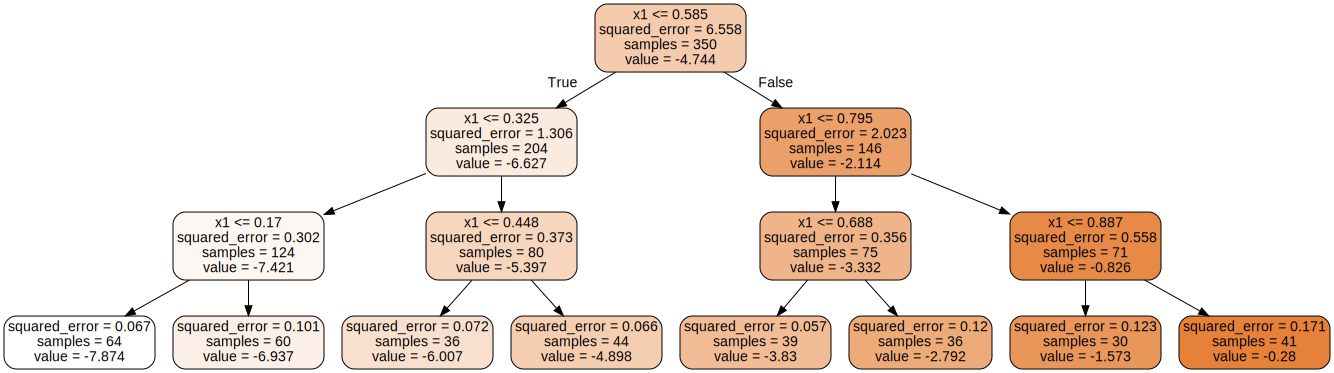

In [7]:
export_graphviz(
        tree_reg,
        out_file=os.path.join(".", "regression_tree.dot"),
        feature_names=["x1"],
        rounded=True,
        filled=True
    )

Source.from_file(os.path.join(".", "regression_tree.dot"))

In [11]:
def plot_regression_predictions(tree_reg, X, y, axes=[0, 1, -8, 0]):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)
    plt.axis(axes)
    plt.xlabel("$x_1$", fontsize=18)
    plt.ylabel("$y$", fontsize=18, rotation=0)
    plt.plot(X, y, "b.")
    plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")

<function matplotlib.pyplot.show(close=None, block=None)>

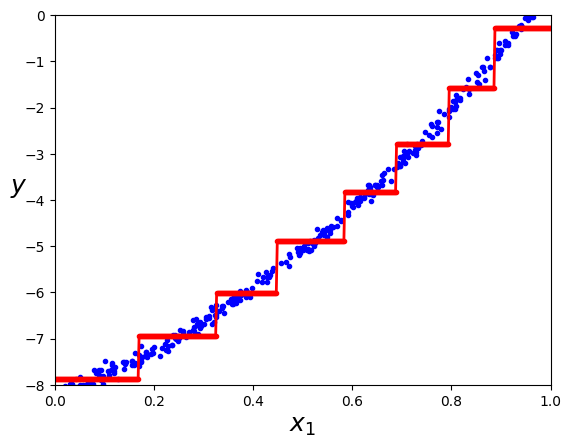

In [12]:
plot_regression_predictions(tree_reg, X, y)
plt.show

# 2. Bagging Classification

Use the digits dataset to perform a classification task using bagging. Set the number of estimators to 200. The test split should be 15% of the initial dataset. Print the accuracy of the model.

In [21]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [18]:
digit_dataset = load_digits()

X_train, X_test, y_train, y_test = train_test_split(digit_dataset['data'],
                                                    digit_dataset['target'],
                                                    test_size = 0.15,
                                                    random_state = 42)

In [20]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators = 200,
    max_samples = 100,
    bootstrap = True,
    random_state = 42)

bag_clf.fit(X_train, y_train)

y_pred = bag_clf.predict(X_test)

In [22]:
print(accuracy_score(y_test, y_pred))

0.9259259259259259


# 3. Gradient Boosting Regression
Use the following regression dataset:

```python
X = np.random.rand(160,1) - 1
y = 2*(X[:, 0])**2 + 0.2*np.random.randn(160)
```

in order to perform gradient boosting. The GradientBoostingRegressor class has the hyperparameters: max_depth=2 and n_estimators=100. The test split is 25% of the initial dataset. Use early stopping to find the optimal number of trees and plot:

- the model's predictions with 100 estimators;
- the model's predictions with the optimal number of trees.

In [31]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

In [26]:
np.random.seed(42)

X = np.random.rand(160,1) - 1
y = 2*(X[:, 0])**2 + 0.2*np.random.randn(160)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.25,
                                                    random_state = 42
                                                    )


In [30]:
gbrt = GradientBoostingRegressor(max_depth = 2,
                                 n_estimators = 100,
                                 random_state = 42)
gbrt.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=2, random_state=42)

In [33]:
errors = [mean_squared_error(y_test, y_pred)
          for y_pred in gbrt.staged_predict(X_test)]

bst_n_estimators = np.argmin(errors) + 1

In [34]:
gbrt_best = GradientBoostingRegressor(max_depth=2, n_estimators=bst_n_estimators, random_state=42)
gbrt_best.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=2, n_estimators=np.int64(39),
                          random_state=42)

In [35]:
def plot_predictions(regressors, X, y, axes, label=None, style="r-", data_style="b.", data_label=None):
    x1 = np.linspace(axes[0], axes[1], 500)
    y_pred = sum(regressor.predict(x1.reshape(-1, 1)) for regressor in regressors)
    plt.plot(X[:, 0], y, data_style, label=data_label)
    plt.plot(x1, y_pred, style, linewidth=2, label=label)
    if label or data_label:
        plt.legend(loc="upper center", fontsize=16)
    plt.axis(axes)

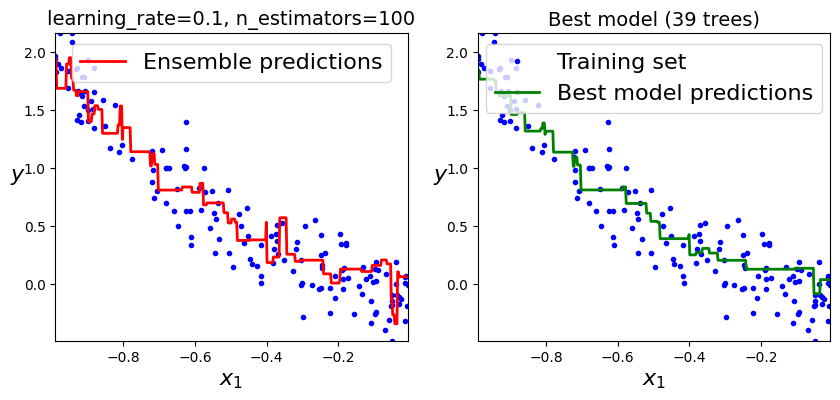

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(121)
plot_predictions([gbrt], X, y, axes=[X[:,0].min(), X[:,0].max(), y.min(), y.max()], label="Ensemble predictions")
plt.title("learning_rate={}, n_estimators={}".format(gbrt.learning_rate, gbrt.n_estimators), fontsize=14)
plt.ylabel("$y$", fontsize=16, rotation=0)
plt.xlabel("$x_1$", fontsize=16)

plt.subplot(122)
plot_predictions([gbrt_best], X, y, axes=[X[:,0].min(), X[:,0].max(), y.min(), y.max()], label="Best model predictions", style="g-", data_label="Training set")
plt.title("Best model (%d trees)" % bst_n_estimators, fontsize=14)
plt.ylabel("$y$", fontsize=16, rotation=0)
plt.xlabel("$x_1$", fontsize=16)

plt.show()
